**1) Loading the Taxis Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load the 'taxis' dataset
df = sns.load_dataset("taxis")
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


**2) Handling Missing Values**

In [ ]:
type(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [ ]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [ ]:
Null_Check = df.isnull().sum()
Null_Check

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [ ]:
cat_columns = df.select_dtypes('object')
cat_columns

,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...
6428,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [ ]:
for i in cat_columns:
  df[i] = df[i].fillna(df[i].mode()[0])

In [ ]:
Null_Check

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [ ]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
Null_Check.sum()

np.int64(186)

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0


**3) Visualizations using Matplotlib/Pandas Plot:**

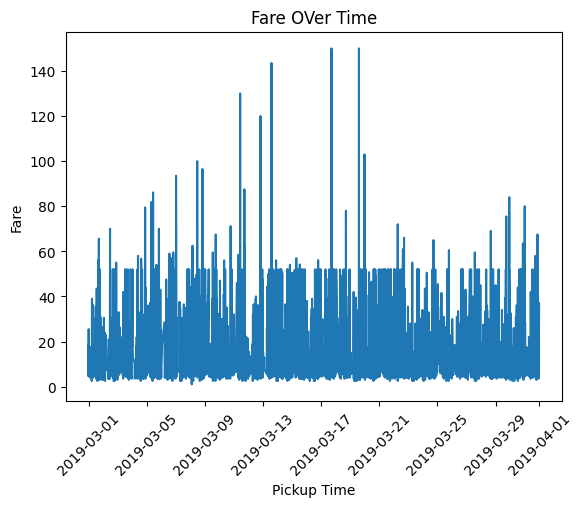

In [ ]:
df['pickup'] = pd.to_datetime(df['pickup'])
df = df.sort_values('pickup')

plt.figure()
plt.plot(df['pickup'] , df['fare'])
plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.title('Fare OVer Time')
plt.xticks(rotation= 45)
plt.show()

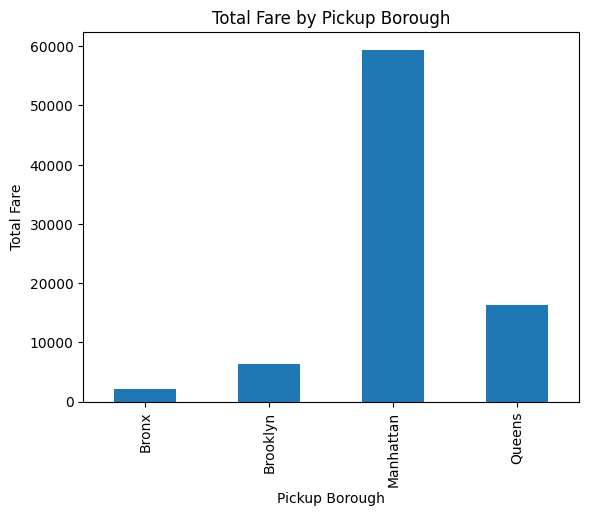

In [ ]:
pickup_borough_fare = df.groupby('pickup_borough') ['fare'].sum()

plt.figure()
pickup_borough_fare.plot(kind= 'bar')
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.title("Total Fare by Pickup Borough")
plt.show()

In [ ]:
payment_method_count = df.groupby('payment').value_counts()
payment_method_count

payment      pickup               dropoff              passengers  distance  fare  tip   tolls  total  color   pickup_zone                dropoff_zone                   pickup_borough  dropoff_borough
cash         2019-02-28 23:29:03  2019-02-28 23:32:35  1           0.90      5.0   0.00  0.00   6.30   green   Old Astoria                Long Island City/Queens Plaza  Queens          Queens             1
             2019-03-01 00:30:59  2019-03-01 00:37:39  2           1.35      7.0   0.00  0.00   8.30   green   Astoria                    Queensbridge/Ravenswood        Queens          Queens             1
             2019-03-01 02:55:55  2019-03-01 02:57:59  3           0.74      4.0   0.00  0.00   7.80   yellow  Clinton East               West Chelsea/Hudson Yards      Manhattan       Manhattan          1
             2019-03-01 05:18:21  2019-03-01 05:18:30  2           0.04      2.5   0.00  0.00   3.80   yellow  Midtown Center             Upper East Side North          Manhattan       Manhattan          1
             2019-03-01 05:23:59  2019-03-01 05:27:33  1           0.70      4.5   0.00  0.00   8.30   yellow  Times Sq/Theatre District  Clinton East                   Manhattan       Manhattan          1
                                                                                                                                                                                                           ..
credit card  2019-03-31 22:07:15  2019-03-31 22:36:31  1           7.62      27.0  8.00  6.12   44.92  yellow  LaGuardia Airport          Murray Hill                    Queens          Manhattan          1
             2019-03-31 22:13:37  2019-03-31 22:22:50  1           1.00      7.5   0.70  0.00   12.00  yellow  SoHo                       Lower East Side                Manhattan       Manhattan          1
             2019-03-31 22:32:27  2019-03-31 22:34:45  1           0.40      3.5   1.45  0.00   8.75   yellow  Midtown North              Lincoln Square East            Manhattan       Manhattan          1
             2019-03-31 22:51:53  2019-03-31 22:55:10  1           0.67      4.5   1.66  0.00   9.96   yellow  West Village               Meatpacking/West Village West  Manhattan       Manhattan          1
             2019-03-31 23:15:03  2019-03-31 23:27:12  1           3.03      11.5  3.82  0.00   19.12  yellow  Midtown East               Upper West Side South          Manhattan       Manhattan          1
Name: count, Length: 6433, dtype: int64

In [ ]:
payment_count = df['payment'].value_counts()
payment_count

,count
payment,
credit card,4621
cash,1812


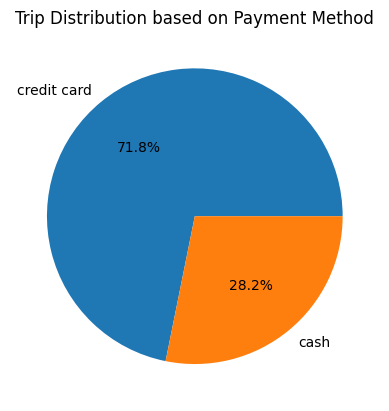

In [ ]:
payment_count = df['payment'].value_counts()
plt.figure()
plt.pie(payment_count, labels= payment_count.index, autopct= '%1.1f%%')
plt.title("Trip Distribution based on Payment Method")
plt.show()

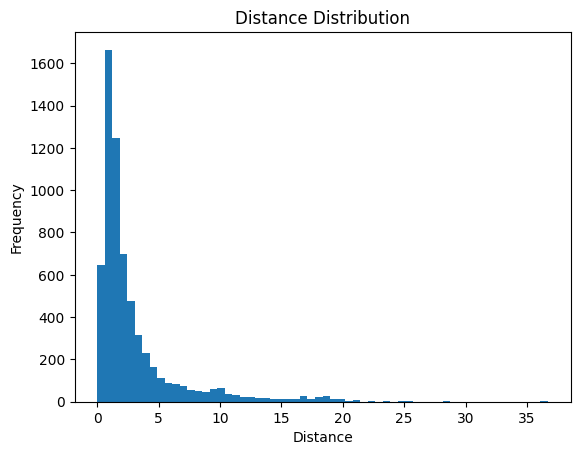

In [ ]:
plt.figure()
plt.hist(df['distance'], bins=60 )
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distance Distribution')
plt.show()

<Figure size 640x480 with 0 Axes>

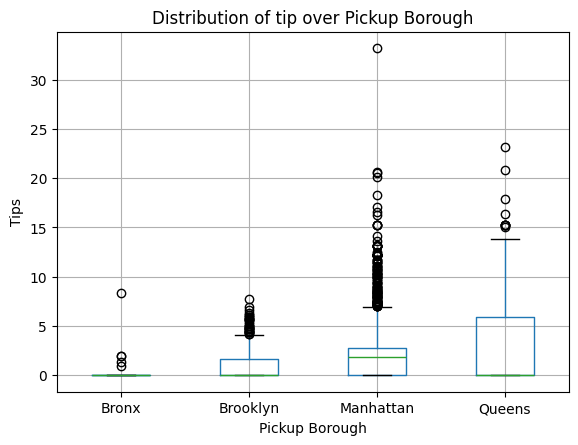

In [ ]:
plt.figure()
df.boxplot(column= 'tip', by= 'pickup_borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Tips')
plt.title('Distribution of tip over Pickup Borough')
plt.suptitle("")
plt.show()

**Visualizations using Seaborn**

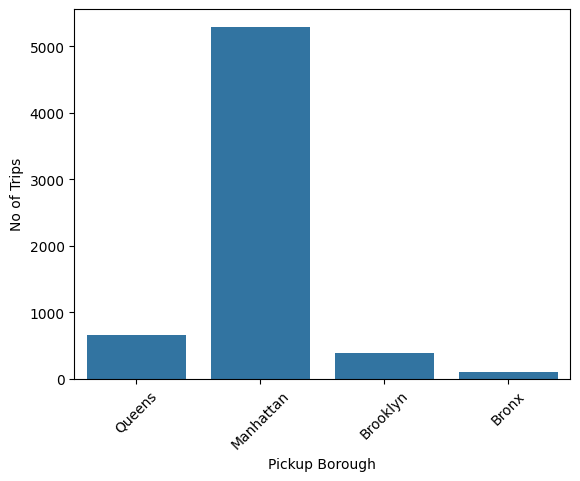

In [ ]:
plt.figure()
sns.countplot(x='pickup_borough' , data=df)
plt.xticks(rotation=45)
plt.xlabel('Pickup Borough')
plt.ylabel('No of Trips')
plt.show()

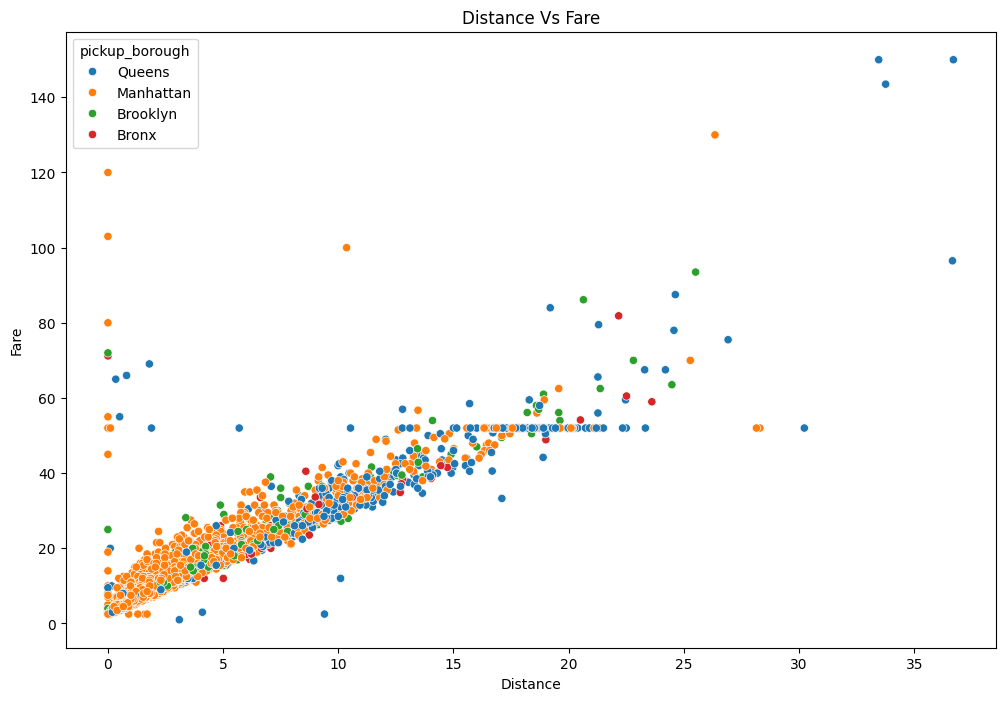

In [ ]:
plt.figure(figsize= (12,8))
sns.scatterplot(x= 'distance' , y= 'fare' , hue= 'pickup_borough' , data=df)
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.title('Distance Vs Fare')
plt.show()

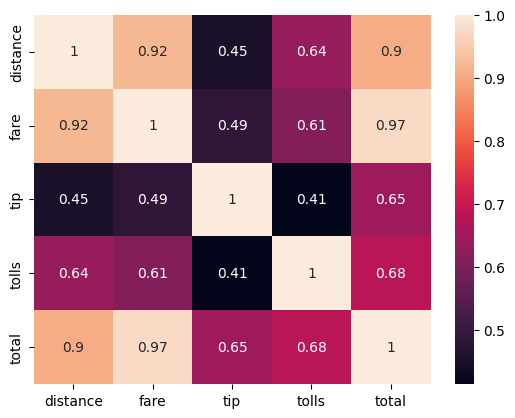

In [ ]:
plt.figure()
correlation= df[['distance' , 'fare' , 'tip' , 'tolls' , 'total']].corr()
sns.heatmap(correlation,  annot= True)
plt.show()

<Figure size 640x480 with 0 Axes>

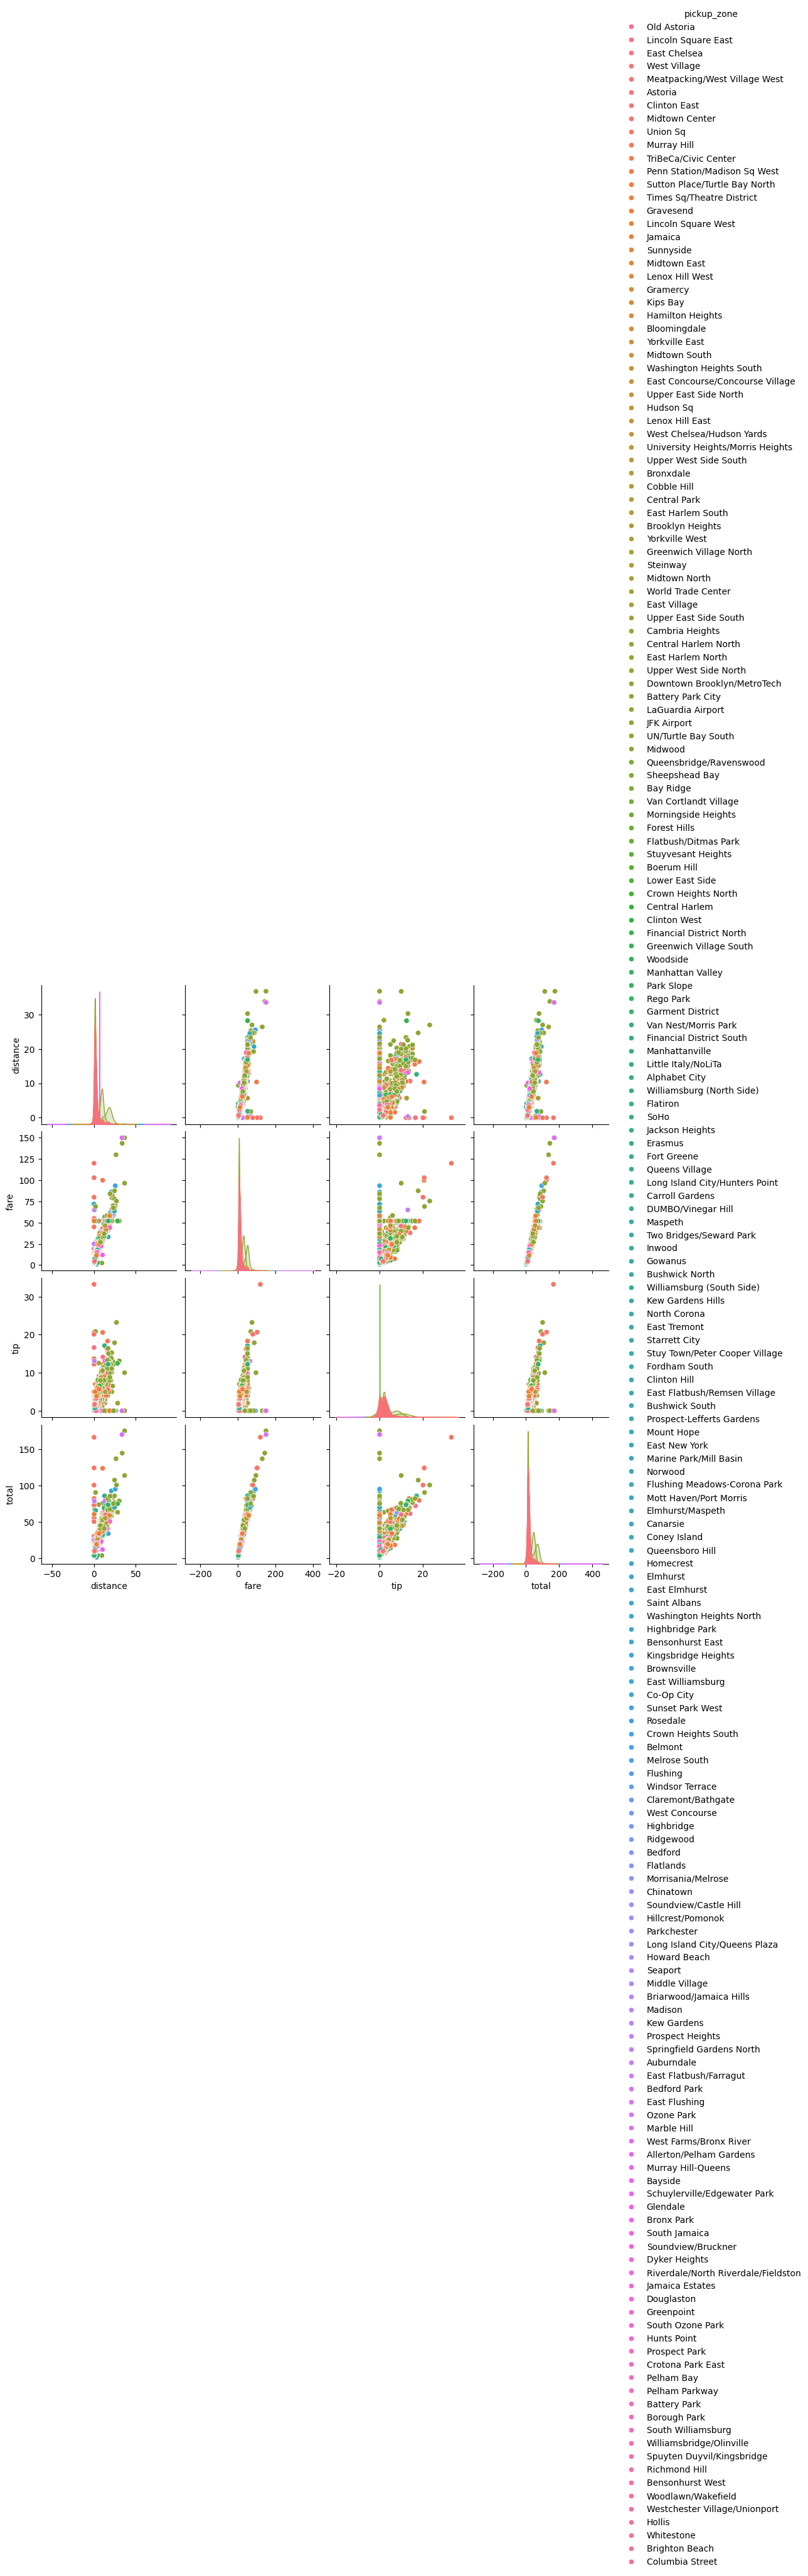

In [ ]:
plt.figure()
sns.pairplot(df[['distance' , 'fare' , 'tip' , 'total' , 'pickup_zone']] , hue= 'pickup_zone')
plt.show()

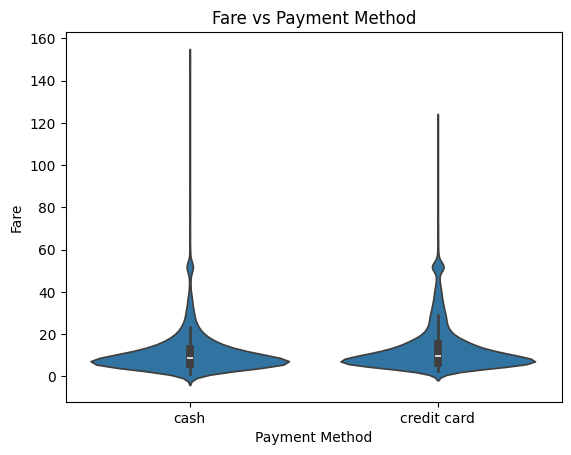

In [ ]:
plt.figure()
sns.violinplot(x= 'payment' , y='fare' , data=df)
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.title('Fare vs Payment Method')
plt.show()